In [1]:
import  numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.metrics import mean_squared_error as mse
from sklearn.gaussian_process import GaussianProcessRegressor as GPR
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, WhiteKernel
from sklearn.kernel_ridge import KernelRidge
from sklearn.gaussian_process.kernels import ExpSineSquared, WhiteKernel
from sklearn.ensemble import RandomForestRegressor as RF

In [2]:
df= pd.read_csv('/content/yATGC.csv')
df

,TF,Max,Min,Mean,Target
0,9.920000e-07,0.000108,751000.0,0.05330,yA
1,2.790000e-06,0.000304,2110000.0,0.15000,yA
2,3.140000e-05,0.003420,23800000.0,1.69000,yA
3,1.600000e-05,0.001740,12100000.0,0.85800,yA
4,2.120000e-06,0.000231,1600000.0,0.11400,yA
...,...,...,...,...,...
1995,1.400000e-09,0.000013,25800000.0,0.00568,yC
1996,1.410000e-09,0.000013,26000000.0,0.00572,yC
1997,1.420000e-09,0.000013,26200000.0,0.00577,yC
1998,1.440000e-09,0.000013,26400000.0,0.00581,yC


In [3]:
from sklearn.utils import shuffle
df1 = shuffle(df, random_state=42)
x_1 = df1.iloc[:,0:4]
x_1

,TF,Max,Min,Mean
1860,2.510000e-10,2.370000e-06,4630000.0,0.001020
353,9.790000e-10,1.070000e-07,742.0,0.000053
1333,3.220000e-10,3.620000e-06,1780.0,0.001330
905,1.860000e-11,1.790000e-06,466000.0,0.000819
1289,2.520000e-11,2.820000e-07,139.0,0.000104
...,...,...,...,...
1130,1.460000e-08,1.630000e-04,80400.0,0.059900
1294,2.370000e-11,2.660000e-07,131.0,0.000098
860,4.460000e-12,4.290000e-07,112000.0,0.000196
1459,8.800000e-09,9.880000e-05,48600.0,0.036200


In [4]:
y_1 = df1["Target"]
y_1

1860    yC
353     yA
1333    yG
905     yT
1289    yG
        ..
1130    yG
1294    yG
860     yT
1459    yG
1126    yG
Name: Target, Length: 2000, dtype: object

In [5]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_1, y_1, test_size=0.20, random_state=42)
x_train.to_csv("x_train.csv")
x_train

,TF,Max,Min,Mean
258,2.350000e-09,2.560000e-07,1780.0,0.000126
743,1.780000e-10,1.720000e-05,4470000.0,0.007860
1393,3.030000e-08,3.400000e-04,167000.0,0.125000
774,5.800000e-12,5.580000e-07,145000.0,0.000256
650,6.630000e-10,6.380000e-05,16600000.0,0.029200
...,...,...,...,...
132,2.290000e-07,2.500000e-05,174000.0,0.012300
1889,4.560000e-10,4.310000e-06,8410000.0,0.001850
869,4.450000e-12,4.280000e-07,111000.0,0.000196
1212,3.000000e-10,3.370000e-06,1660.0,0.001230


In [6]:
y_train.to_csv("y_train.csv")
y_train

258     yA
743     yT
1393    yG
774     yT
650     yT
        ..
132     yA
1889    yC
869     yT
1212    yG
183     yA
Name: Target, Length: 1600, dtype: object

In [7]:
x_test.to_csv("x_test.csv")
x_test

,TF,Max,Min,Mean
1522,5.270000e-07,4.970000e-03,9.700000e+09,2.130000
1610,6.360000e-10,6.000000e-06,1.170000e+07,0.002570
568,4.330000e-11,4.160000e-06,1.080000e+06,0.001910
1801,6.350000e-11,5.990000e-07,1.170000e+06,0.000257
90,9.690000e-09,1.060000e-06,7.340000e+03,0.000521
...,...,...,...,...
1548,6.640000e-09,6.260000e-05,1.220000e+08,0.026900
652,5.210000e-10,5.010000e-05,1.300000e+07,0.022900
1636,5.360000e-10,5.050000e-06,9.870000e+06,0.002170
1911,2.420000e-09,2.290000e-05,4.460000e+07,0.009810


In [8]:
y_test.to_csv("y-test.csv")
y_test

1522    yC
1610    yC
568     yT
1801    yC
90      yA
        ..
1548    yC
652     yT
1636    yC
1911    yC
1979    yC
Name: Target, Length: 400, dtype: object

## **KNN**

In [9]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=30)
knn.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=30)

In [10]:
y_pred_knn = knn.predict(x_test)
from sklearn.metrics import accuracy_score

print('Model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, y_pred_knn)))

Model accuracy score: 0.6925


In [11]:
print('Training set score: {:.4f}'.format(knn.score(x_train, y_train)))

print('Test set score: {:.4f}'.format(knn.score(x_test, y_test)))

Training set score: 0.7500
Test set score: 0.6925


In [12]:
from sklearn.metrics import confusion_matrix

cm_kn = confusion_matrix(y_test,y_pred_knn)

In [ ]:
knn.get_params()

{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 30,
 'p': 2,
 'weights': 'uniform'}

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           2       0.96      0.96      0.96       100
           3       0.96      0.96      0.96       100

    accuracy                           0.96       200
   macro avg       0.96      0.96      0.96       200
weighted avg       0.96      0.96      0.96       200



In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support
import seaborn as sns
cm = confusion_matrix(y_pred_knn, y_test)
cm_df = pd.DataFrame(cm,
                     index = ['dAMP','dCMP','dGMP', 'dTMP'],
                     columns = ['dAMP','dCMP','dGMP', 'dTMP'])

#sns.heatmap(cm_df, cbar=True,annot=True,cmap="PiYG",fmt="d",annot_kws={"size": 15})
sns.heatmap(cm_df, cbar=True,annot=True,fmt="d",annot_kws={"size": 15})

plt.ylabel('True Nucelotides', fontsize = 15,weight='bold')
plt.xlabel('Predicted Nucleotides', fontsize = 15,weight='bold')
plt.title('KNN Confusion Matrix', fontsize = 15,weight='bold')
plt.xticks(weight='bold')
plt.yticks(weight='bold')
plt.show()

ValueError: Shape of passed values is (2, 2), indices imply (4, 4)

## **SVM**

In [13]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
svc=SVC()
svc.get_params()

{'C': 1.0,
 'break_ties': False,
 'cache_size': 200,
 'class_weight': None,
 'coef0': 0.0,
 'decision_function_shape': 'ovr',
 'degree': 3,
 'gamma': 'scale',
 'kernel': 'rbf',
 'max_iter': -1,
 'probability': False,
 'random_state': None,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

In [14]:
svc.fit(x_train,y_train)

SVC()

In [15]:
y_pred=svc.predict(x_test)
print('Model accuracy score with default hyperparameters: {0:0.4f}'. format(accuracy_score(y_test, y_pred)))

Model accuracy score with default hyperparameters: 0.2400


In [ ]:
print('Training set score: {:.4f}'.format(svc.score(x_train, y_train)))

print('Test set score: {:.4f}'.format(svc.score(x_test, y_test)))

Training set score: 0.2644
Test set score: 0.2400


## **DTC_gini**

In [16]:
from sklearn.tree import DecisionTreeClassifier
# Assuming x_train, x_test, y_train, y_test are defined elsewhere in your code
dnn1 = DecisionTreeClassifier(criterion='gini', max_depth=23, random_state=65)
dnn1.fit(x_train, y_train)
y_pred_dnn1 = dnn1.predict(x_test)

In [17]:
print('Model accuracy score with criterion gini index: {0:0.4f}'. format(accuracy_score(y_test, y_pred_dnn1)))

Model accuracy score with criterion gini index: 0.9875


In [18]:
print('Training set score: {:.4f}'.format(dnn1.score(x_train, y_train)))

print('Test set score: {:.4f}'.format(dnn1.score(x_test, y_test)))

Training set score: 0.9994
Test set score: 0.9875


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_dnn1))

              precision    recall  f1-score   support

          yA       0.99      0.99      0.99       106
          yC       1.00      0.97      0.98        96
          yG       0.98      0.99      0.99       107
          yT       0.98      1.00      0.99        91

    accuracy                           0.99       400
   macro avg       0.99      0.99      0.99       400
weighted avg       0.99      0.99      0.99       400



In [ ]:
dnn1.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': 23,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'random_state': 65,
 'splitter': 'best'}

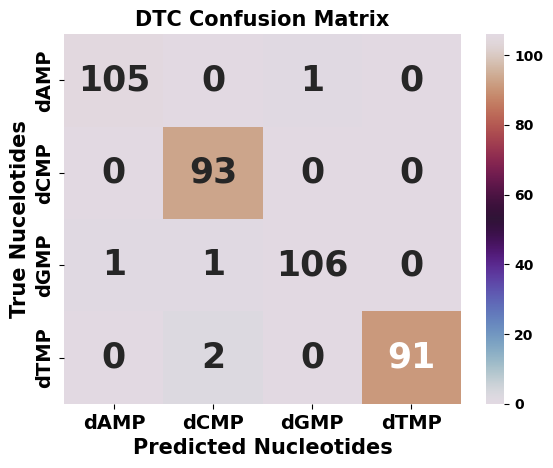

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support
import seaborn as sns
cm = confusion_matrix(y_pred_dnn1, y_test)
cm_df = pd.DataFrame(cm,
                     index = ['dAMP','dCMP','dGMP', 'dTMP'],
                     columns = ['dAMP','dCMP','dGMP', 'dTMP'])

#sns.heatmap(cm_df, cbar=True,annot=True,cmap="brg",fmt="d",annot_kws={"size": 15})
sns.heatmap(cm_df, cbar=True,annot=True,cmap="twilight", fmt="d",annot_kws={"size": 25, 'fontweight': 'bold'})

plt.ylabel('True Nucelotides', fontsize = 15,weight='bold')
plt.xlabel('Predicted Nucleotides', fontsize = 15,weight='bold')
plt.title('DTC Confusion Matrix', fontsize = 15,weight='bold')
plt.xticks(fontsize=14, weight='bold')
plt.yticks(fontsize=14, weight='bold')
plt.show()

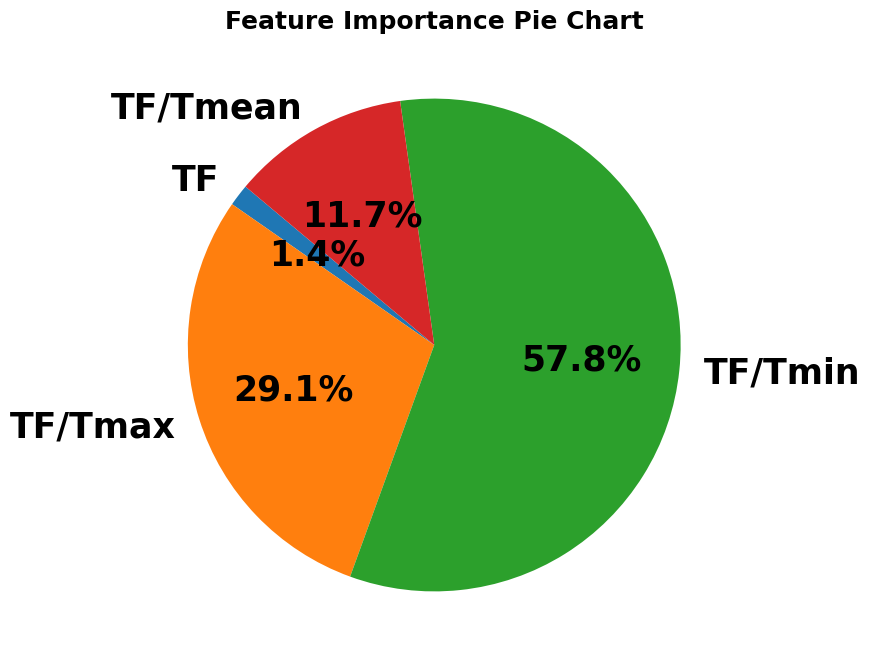

In [ ]:
feature_importances = dnn1.feature_importances_

# Get the names of the features (replace with your feature names if available)
feature_names = ["TF", "TF/Tmax", "TF/Tmin", "TF/Tmean"]
# Create a pie chart
plt.figure(figsize=(8, 8))
patches, texts, autotexts = plt.pie(feature_importances, labels=feature_names, autopct='%1.1f%%', startangle=140,textprops={'fontsize': 54})

# Increase font size and make feature names bold
for text in texts + autotexts:
    text.set_size(25)  # Adjust the font size as needed
    text.set_weight('bold')

plt.title('Feature Importance Pie Chart', fontsize=18, weight='bold')
plt.show()

In [ ]:
pip install shap

## **SHAP**

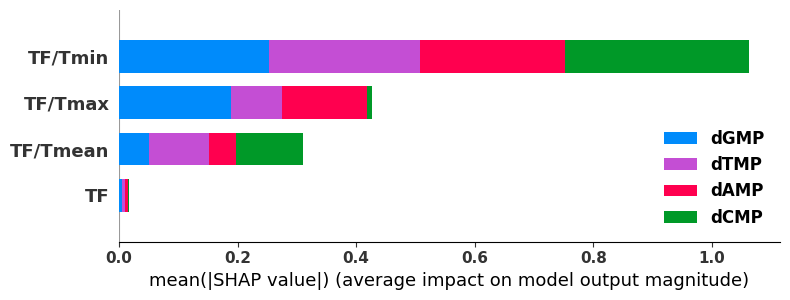

In [ ]:
import shap
import pandas as pd
import matplotlib.pyplot as plt
#feature_names = list(x_test.columns)
class_names = ['dAMP','dCMP','dGMP','dTMP']

# Create the SHAP explainer with the trained model
explainer = shap.TreeExplainer(dnn1)

# Compute SHAP valuesfc
shap_values = explainer.shap_values(x_test)
class_colors = ["#E69F00", "#56B4E9", "#D55E00", "#0073C2"]
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['text.color'] = 'black'
# Plot the SHAP summary plot
shap.summary_plot(shap_values, x_test, plot_type="bar", class_names=class_names, feature_names=feature_names)
plt.show()

## **CV**

In [ ]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestClassifier  # Replace with your actual model
#X = x_train
#y = y_train

num_folds = 10

kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

accuracy_scores = cross_val_score(dnn1, x_1, y_1, cv=kf, scoring='accuracy')

for i, accuracy in enumerate(accuracy_scores):
    print(f'Fold {i + 1} Accuracy: {accuracy:.4f}')
mean_accuracy = accuracy_scores.mean()
std_dev_accuracy = accuracy_scores.std()
print(f'\nMean Accuracy: {mean_accuracy:.4f} (±{std_dev_accuracy:.4f})')

Fold 1 Accuracy: 0.9800
Fold 2 Accuracy: 0.9850
Fold 3 Accuracy: 0.9950
Fold 4 Accuracy: 0.9850
Fold 5 Accuracy: 0.9800
Fold 6 Accuracy: 0.9850
Fold 7 Accuracy: 0.9850
Fold 8 Accuracy: 0.9800
Fold 9 Accuracy: 0.9700
Fold 10 Accuracy: 0.9850

Mean Accuracy: 0.9830 (±0.0060)


## **ROC_AUC**

In [ ]:
from sklearn.metrics import roc_curve, auc

No positive samples in y_true, true positive value should be meaningless
No positive samples in y_true, true positive value should be meaningless
No positive samples in y_true, true positive value should be meaningless
No positive samples in y_true, true positive value should be meaningless


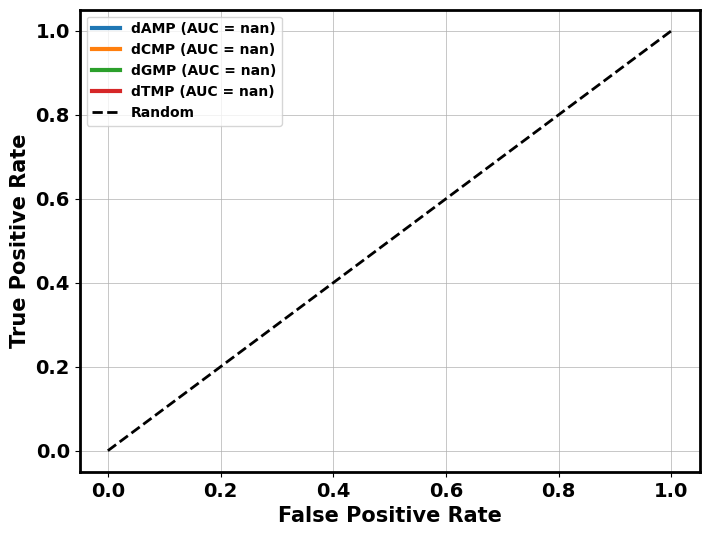

In [ ]:
dnn1.fit(x_train, y_train)

# Get probabilities for each class
y_score = dnn1.predict_proba(x_test)

# Get the number of unique classes in y
n_classes = len(np.unique(y_train))

# Assign class names to the classes
class_names = {0: 'dAMP', 1: 'dCMP', 2: 'dGMP', 3: 'dTMP'}

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    # Convert labels to binary for each class
    y_binary = (y_test == i).astype(int)

    fpr[i], tpr[i], _ = roc_curve(y_binary, y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(8, 6))

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})', linewidth=3)

plt.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=2)
plt.xlabel('False Positive Rate', fontsize = 15,weight='bold')
plt.ylabel('True Positive Rate', fontsize = 15,weight='bold')
#plt.title('ROC Curve for Multiclass Classification', fontsize = 18,weight='bold')
plt.grid(which='both', linestyle='-', linewidth=0.5)
plt.xticks(fontsize=14, weight='bold')
plt.yticks(fontsize=14, weight='bold')
ax = plt.gca()
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
plt.legend(loc='best')
plt.rcParams['font.weight'] = 'bold'
plt.show()

## **DTC_entropy**

In [19]:
dnn = DecisionTreeClassifier(criterion='entropy', max_depth=22, random_state=35)
dnn.fit(x_train, y_train)
y_pred_dnn = dnn.predict(x_test)

In [20]:
print('Model accuracy score with criterion gini index: {0:0.4f}'. format(accuracy_score(y_test, y_pred_dnn)))

Model accuracy score with criterion gini index: 0.9775


In [21]:
print('Training set score: {:.4f}'.format(dnn.score(x_train, y_train)))

print('Test set score: {:.4f}'.format(dnn.score(x_test, y_test)))

Training set score: 0.9994
Test set score: 0.9775


In [22]:
dnn.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'entropy',
 'max_depth': 22,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'random_state': 35,
 'splitter': 'best'}

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_dnn))

              precision    recall  f1-score   support

          yA       0.99      0.99      0.99       106
          yC       1.00      0.93      0.96        96
          yG       0.99      0.99      0.99       107
          yT       0.93      1.00      0.96        91

    accuracy                           0.98       400
   macro avg       0.98      0.98      0.98       400
weighted avg       0.98      0.98      0.98       400



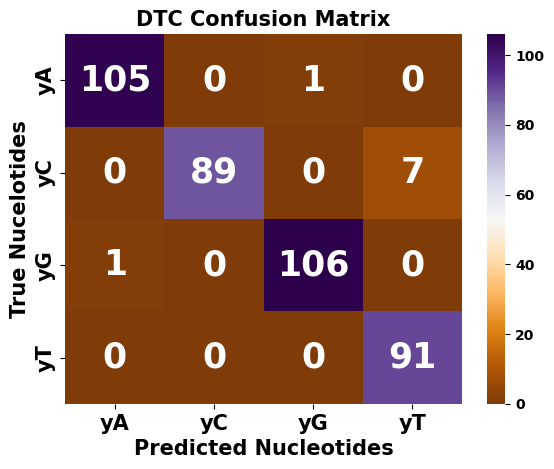

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support
import seaborn as sns
cm = confusion_matrix(y_test, y_pred_dnn)
cm_df = pd.DataFrame(cm,
                     index = ['yA','yC','yG', 'yT'],
                     columns = ['yA','yC','yG', 'yT'])

sns.heatmap(cm_df, cbar=True,annot=True,cmap="PuOr",fmt="d",annot_kws={"size": 25})
plt.ylabel('True Nucelotides', fontsize = 15,weight='bold')
plt.xlabel('Predicted Nucleotides', fontsize = 15,weight='bold')
plt.title('DTC Confusion Matrix', fontsize = 15,weight='bold')
plt.xticks(fontsize=15,weight='bold')
plt.yticks(fontsize=15,weight='bold')
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestClassifier  # Replace with your actual model
#X = x_train
#y = y_train

num_folds = 10

kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

accuracy_scores = cross_val_score(dnn, x_1, y_1, cv=kf, scoring='accuracy')

for i, accuracy in enumerate(accuracy_scores):
    print(f'Fold {i + 1} Accuracy: {accuracy:.4f}')
mean_accuracy = accuracy_scores.mean()
std_dev_accuracy = accuracy_scores.std()
print(f'\nMean Accuracy: {mean_accuracy:.4f} (±{std_dev_accuracy:.4f})')

Fold 1 Accuracy: 0.9750
Fold 2 Accuracy: 0.9800
Fold 3 Accuracy: 0.9850
Fold 4 Accuracy: 0.9900
Fold 5 Accuracy: 0.9750
Fold 6 Accuracy: 0.9900
Fold 7 Accuracy: 0.9950
Fold 8 Accuracy: 0.9800
Fold 9 Accuracy: 0.9700
Fold 10 Accuracy: 0.9800

Mean Accuracy: 0.9820 (±0.0075)


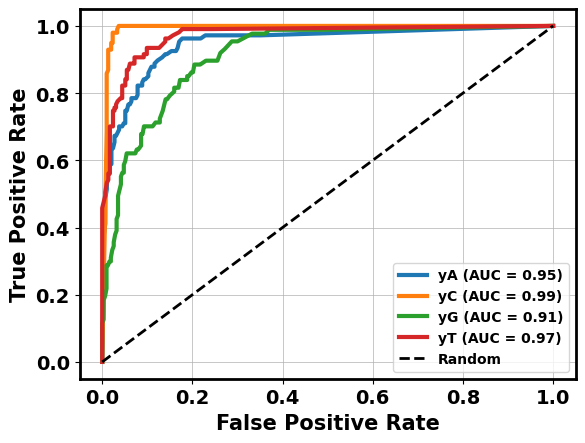

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc

# Generating synthetic data with four classes using make_classification
x, y = make_classification(
    n_samples=2000,
    n_features=4,
    n_classes=4,
    n_clusters_per_class=1,
    random_state=42
)

# Splitting the data into train and test sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Initialize the RandomForestClassifier (or any classifier of your choice)
#model = DecisionTreeClassifier()

# Train the model
dnn.fit(x_train, y_train)

# Get probabilities for each class
y_score = model.predict_proba(x_test)

# Get the number of unique classes in y
n_classes = len(np.unique(y))
# Assign class names to the classes
class_names = {0: 'yA', 1: 'yC', 2: 'yG', 3: 'yT'}

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test == i, y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
#plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})', linewidth=3)
    #plt.plot(fpr[i], tpr[i], label=f'class_names=class_names')

plt.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=2)
plt.xlabel('False Positive Rate', fontsize = 15,weight='bold')
plt.ylabel('True Positive Rate', fontsize = 15,weight='bold')
#plt.title('ROC Curve for Multiclass Classification', fontsize = 18,weight='bold')
plt.grid(which='both', linestyle='-', linewidth=0.5)
plt.xticks(fontsize=14, weight='bold')
plt.yticks(fontsize=14, weight='bold')
ax = plt.gca()
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
plt.legend(loc='best')
plt.rcParams['font.weight'] = 'bold'
plt.show()

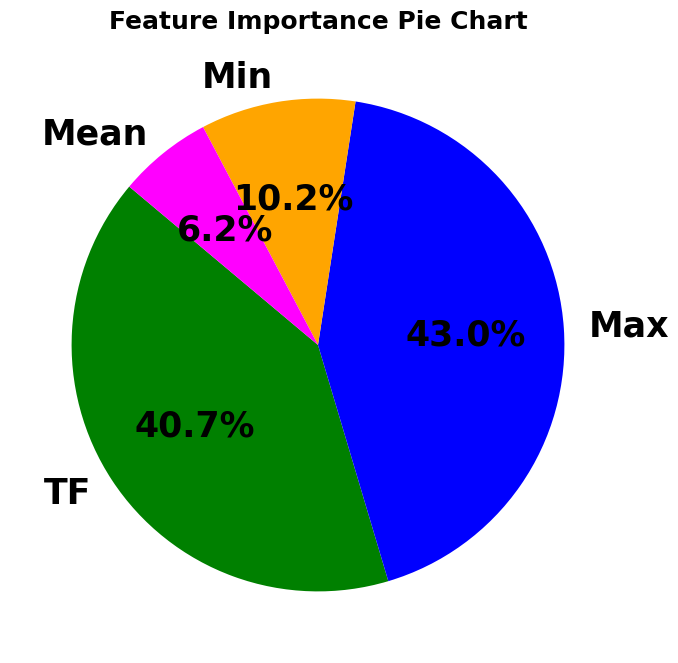

In [ ]:
feature_importances = dnn.feature_importances_

# Get the names of the features (replace with your feature names if available)
feature_names = ["TF", "Max", "Min", "Mean"]
# Create a pie chart
plt.figure(figsize=(8, 8))
patches, texts, autotexts = plt.pie(feature_importances, labels=feature_names, autopct='%1.1f%%', startangle=140,textprops={'fontsize': 54}, colors=['green', 'blue', 'orange','magenta'])

# Increase font size and make feature names bold
for text in texts + autotexts:
    text.set_size(25)  # Adjust the font size as needed
    text.set_weight('bold')

plt.title('Feature Importance Pie Chart', fontsize=18, weight='bold')
plt.show()

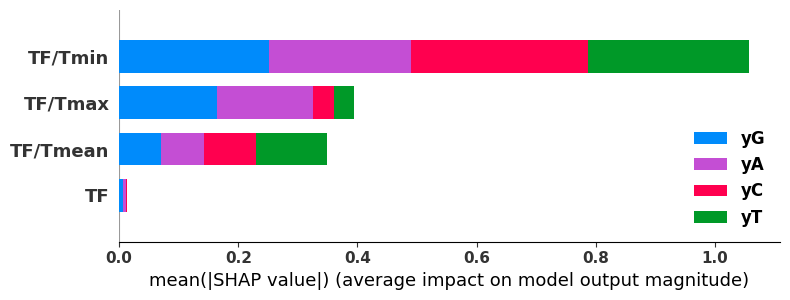

In [ ]:
import shap
import pandas as pd
import matplotlib.pyplot as plt
#feature_names = list(x_test.columns)
class_names = ['yA','yC','yG','yT']

# Create the SHAP explainer with the trained model
explainer = shap.TreeExplainer(dnn)

# Compute SHAP valuesfc
shap_values = explainer.shap_values(x_test)
class_colors = ["#E69F00", "#56B4E9", "#D55E00", "#0073C2"]
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['text.color'] = 'black'
# Plot the SHAP summary plot
shap.summary_plot(shap_values, x_test, plot_type="bar", class_names=class_names, feature_names=feature_names)
plt.show()

## **RFC**

In [23]:
from sklearn.ensemble import RandomForestClassifier

In [24]:
RandomForestClassifier().get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [25]:
rfc = RandomForestClassifier(criterion = 'entropy', random_state=100, max_depth = 25)

In [26]:
rfc.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'entropy',
 'max_depth': 25,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 100,
 'verbose': 0,
 'warm_start': False}

In [27]:
rfc.fit(x_train, y_train)

RandomForestClassifier(criterion='entropy', max_depth=25, random_state=100)

In [28]:
y_pred_rf = rfc.predict(x_test)

In [29]:
from sklearn.metrics import accuracy_score

print('Model accuracy score with 10 decision-trees : {0:0.4f}'. format(accuracy_score(y_test, y_pred_rf)))

Model accuracy score with 10 decision-trees : 0.9925


In [ ]:
print('Training set score: {:.4f}'.format(rfc.score(x_train, y_train)))

print('Test set score: {:.4f}'.format(rfc.score(x_test, y_test)))

Training set score: 0.9988
Test set score: 0.9850


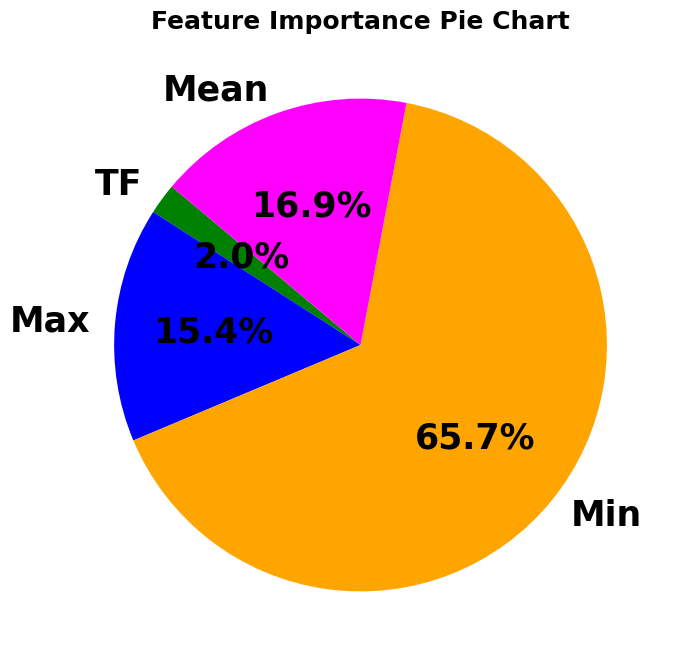

In [ ]:
feature_importances = rfc.feature_importances_

# Get the names of the features (replace with your feature names if available)
feature_names = ["TF", "Max", "Min", "Mean"]
# Create a pie chart
plt.figure(figsize=(8, 8))
patches, texts, autotexts = plt.pie(feature_importances, labels=feature_names, autopct='%1.1f%%', startangle=140,textprops={'fontsize': 54}, colors=['green', 'blue', 'orange','magenta'])

# Increase font size and make feature names bold
for text in texts + autotexts:
    text.set_size(25)  # Adjust the font size as needed
    text.set_weight('bold')

plt.title('Feature Importance Pie Chart', fontsize=18, weight='bold')
plt.show()

In [ ]:
import numpy as np

In [ ]:
feature_scores = pd.Series(rfc.feature_importances_, index=pd.DataFrame(x_train).columns).sort_values(ascending=False)
feature_scores

Min     0.654578
Max     0.160481
Mean    0.150375
TF      0.034566
dtype: float64

In [ ]:
rfc.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'entropy',
 'max_depth': 25,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 100,
 'verbose': 0,
 'warm_start': False}

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           1       0.99      0.98      0.98       100
           3       0.98      0.99      0.99       100

    accuracy                           0.98       200
   macro avg       0.99      0.98      0.98       200
weighted avg       0.99      0.98      0.98       200



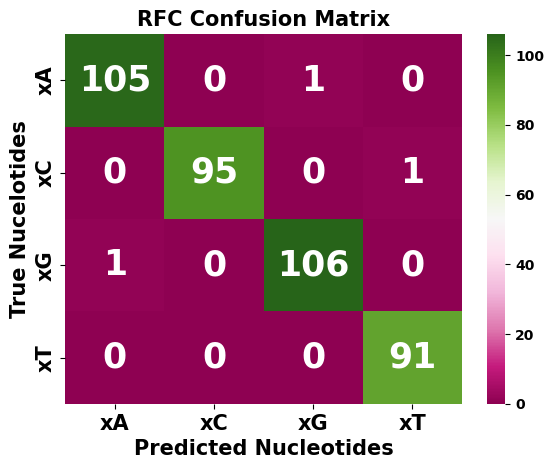

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Assuming y_test and y_pred_rf are defined

cm = confusion_matrix(y_test, y_pred_rf)
cm_df = pd.DataFrame(cm,
                     index=['xA', 'xC', 'xG', 'xT'],
                     columns=['xA', 'xC', 'xG', 'xT'])
colors = ['red', 'yellow']
# Create heatmap with bold annotations
sns.heatmap(cm_df, cbar=True,annot=True,cmap="PiYG", fmt="d",annot_kws={"size": 25, 'fontweight': 'bold'})

plt.ylabel('True Nucelotides', fontsize = 15,weight='bold')
plt.xlabel('Predicted Nucleotides', fontsize = 15,weight='bold')
plt.title('RFC Confusion Matrix', fontsize = 15,weight='bold')
plt.xticks(fontsize=15, weight='bold')
plt.yticks(fontsize=15, weight='bold')
plt.show()


## **ROC_AUC**

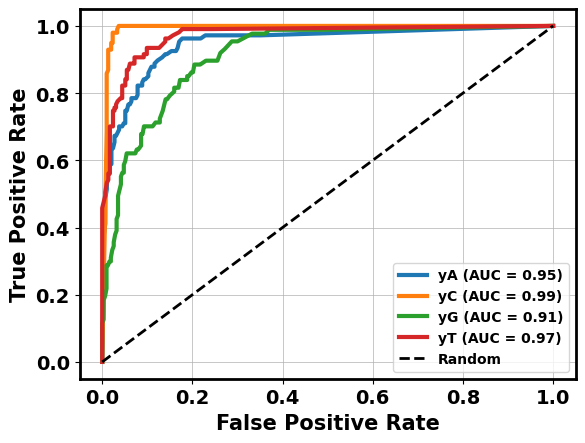

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc

# Generating synthetic data with four classes using make_classification
x, y = make_classification(
    n_samples=2000,
    n_features=4,
    n_classes=4,
    n_clusters_per_class=1,
    random_state=42
)

# Splitting the data into train and test sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Initialize the RandomForestClassifier (or any classifier of your choice)
#model = RandomForestClassifier()

# Train the model
rfc.fit(x_train, y_train)

# Get probabilities for each class
y_score = model.predict_proba(x_test)

# Get the number of unique classes in y
n_classes = len(np.unique(y))
# Assign class names to the classes
class_names = {0: 'yA', 1: 'yC', 2: 'yG', 3: 'yT'}

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test == i, y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
#plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})', linewidth=3)
    #plt.plot(fpr[i], tpr[i], label=f'class_names=class_names')

plt.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=2)
plt.xlabel('False Positive Rate', fontsize = 15,weight='bold')
plt.ylabel('True Positive Rate', fontsize = 15,weight='bold')
#plt.title('ROC Curve for Multiclass Classification', fontsize = 18,weight='bold')
plt.grid(which='both', linestyle='-', linewidth=0.5)
plt.xticks(fontsize=14, weight='bold')
plt.yticks(fontsize=14, weight='bold')
ax = plt.gca()
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
plt.legend(loc='best')
plt.rcParams['font.weight'] = 'bold'
plt.show()


# **Cross_Validation**

In [ ]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestClassifier  # Replace with your actual model
#X = x_train
#y = y_train

num_folds = 10

kf = KFold(n_splits=num_folds, shuffle=True, random_state=65)

accuracy_scores = cross_val_score(rfc, x_1, y_1, cv=kf, scoring='accuracy')

for i, accuracy in enumerate(accuracy_scores):
    print(f'Fold {i + 1} Accuracy: {accuracy:.4f}')
mean_accuracy = accuracy_scores.mean()
std_dev_accuracy = accuracy_scores.std()
print(f'\nMean Accuracy: {mean_accuracy:.4f} (±{std_dev_accuracy:.4f})')


Fold 1 Accuracy: 1.0000
Fold 2 Accuracy: 0.9850
Fold 3 Accuracy: 0.9950
Fold 4 Accuracy: 0.9900
Fold 5 Accuracy: 0.9900
Fold 6 Accuracy: 0.9900
Fold 7 Accuracy: 1.0000
Fold 8 Accuracy: 0.9850
Fold 9 Accuracy: 0.9950
Fold 10 Accuracy: 0.9900

Mean Accuracy: 0.9920 (±0.0051)


## **Unknown Prediction**

In [ ]:
df5= pd.read_csv('/content/yC.csv')
x_t = df5.iloc[:,0:4]
y_t = df5["Target"]

In [ ]:
y_pred_t = rfc.predict(x_t)
print('Model accuracy score with 10 decision-trees : {0:0.4f}'. format(accuracy_score(y_t, y_pred_t)))

Model accuracy score with 10 decision-trees : 0.9980


In [ ]:
y_pred_t

array(['yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC',
       'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC',
       'yC', 'yC', 'yC', 'yT', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC',
       'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC',
       'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC',
       'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC',
       'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC',
       'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC',
       'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC',
       'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC',
       'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC',
       'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC',
       'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC',
       'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'yC', 'y

In [ ]:
from google.colab import files
import pandas as pd
df = pd.DataFrame(y_pred_t)
df.to_csv('xG_pred.csv')
files.download('xG_pred.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **shap**

In [ ]:
!pip install shap

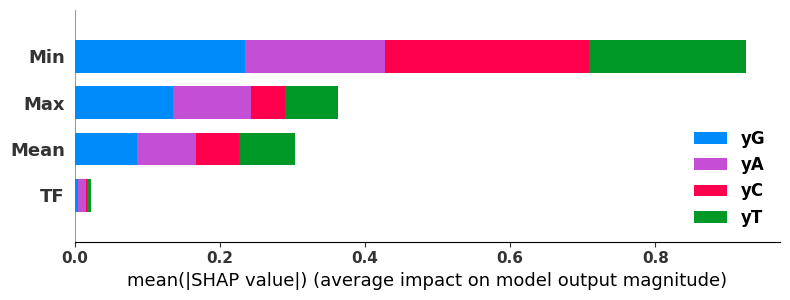

In [ ]:
import shap
import pandas as pd
import matplotlib.pyplot as plt
#feature_names = list(x_test.columns)
class_names = ['yA','yC','yG','yT']

# Create the SHAP explainer with the trained model
explainer = shap.TreeExplainer(rfc)

# Compute SHAP values
shap_values = explainer.shap_values(x_test)
class_colors = ["#E69F00", "#56B4E9", "#D55E00", "#0073C2"]
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['text.color'] = 'black'
# Plot the SHAP summary plot
shap.summary_plot(shap_values, x_test, plot_type="bar", class_names=class_names, feature_names=feature_names)
plt.show()

## **Logistic Regression Model**

In [30]:
# train a logistic regression model on the training set
from sklearn.linear_model import LogisticRegression


# instantiate the model
logreg = LogisticRegression(solver='lbfgs', random_state=35)


# fit the model
logreg.fit(x_train, y_train)

LogisticRegression(random_state=35)

In [31]:
logreg.get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 100,
 'multi_class': 'auto',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': 35,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [32]:
y_pred_logistic = logreg.predict(x_test)

In [33]:
from sklearn.metrics import accuracy_score

print('Model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, y_pred_logistic)))

Model accuracy score: 0.2400


In [34]:
print('Training set score: {:.4f}'.format(logreg.score(x_train, y_train)))

print('Test set score: {:.4f}'.format(logreg.score(x_test, y_test)))

Training set score: 0.2531
Test set score: 0.2400


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_logistic))

              precision    recall  f1-score   support

           0       0.77      0.74      0.75       107
           1       0.84      0.90      0.87        99
           2       0.72      0.70      0.71        87
           3       0.86      0.85      0.85       107

    accuracy                           0.80       400
   macro avg       0.80      0.80      0.80       400
weighted avg       0.80      0.80      0.80       400



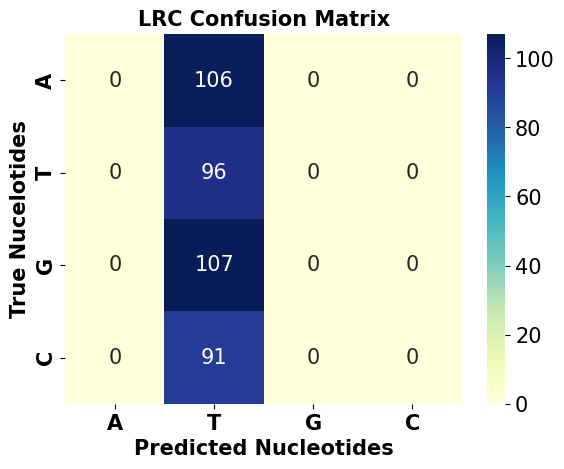

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support
import seaborn as sns
cm = confusion_matrix(y_test, y_pred_logistic)
cm_df = pd.DataFrame(cm,
                     index = ['A','T','G', 'C'],
                     columns = ['A','T','G', 'C'])

sns.heatmap(cm_df, cbar=True,annot=True,cmap="YlGnBu",fmt="d",annot_kws={"size": 15})
plt.ylabel('True Nucelotides', fontsize = 15,weight='bold')
plt.xlabel('Predicted Nucleotides', fontsize = 15,weight='bold')
plt.title('LRC Confusion Matrix', fontsize = 15,weight='bold')
plt.xticks(weight='bold')
plt.yticks(weight='bold')
plt.show()

## **Validation Parameters**

In [ ]:
feature_scores = pd.Series(rfc.feature_importances_, index=x_train.columns).sort_values(ascending=False)
feature_scores

Min     0.489226
Mean    0.196832
TF      0.170668
Max     0.143274
dtype: float64

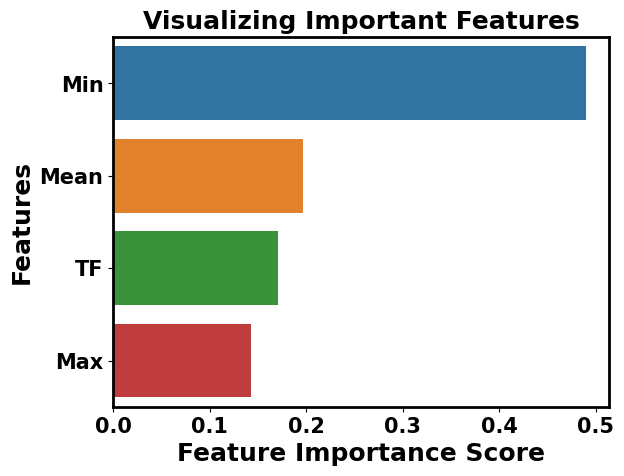

In [ ]:
sns.barplot(x=feature_scores, y=feature_scores.index)
plt.xlabel('Feature Importance Score', fontsize = 18,weight='bold')
plt.xticks(weight='bold')
plt.yticks(weight='bold')
plt.ylabel('Features', fontsize = 18,weight='bold')
plt.title("Visualizing Important Features", fontsize = 18,weight='bold')
plt.show()

## **Gaussian Naive Bayes**

In [35]:
from sklearn.naive_bayes import GaussianNB
model_naive = GaussianNB()
model_naive.fit(x_train, y_train)

GaussianNB()

In [36]:
model_naive.get_params()

{'priors': None, 'var_smoothing': 1e-09}

In [37]:
y_pred_naive = model_naive.predict(x_test)

In [38]:
from sklearn.metrics import accuracy_score

print('Model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, y_pred_naive)))

Model accuracy score: 0.2775


In [39]:
print('Training set score: {:.4f}'.format(model_naive.score(x_train, y_train)))

print('Test set score: {:.4f}'.format(model_naive.score(x_test, y_test)))

Training set score: 0.2550
Test set score: 0.2775


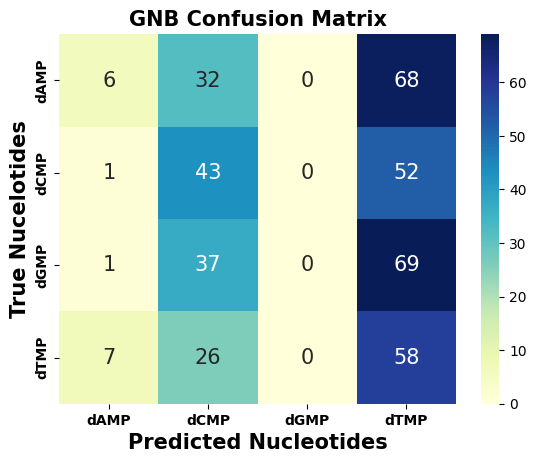

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support
import seaborn as sns
cm = confusion_matrix(y_test, y_pred_naive)
cm_df = pd.DataFrame(cm,
                     index = ['dAMP','dCMP','dGMP', 'dTMP'],
                     columns = ['dAMP','dCMP','dGMP', 'dTMP'])

sns.heatmap(cm_df, cbar=True,annot=True,cmap="YlGnBu",fmt="d",annot_kws={"size": 15})
plt.ylabel('True Nucelotides', fontsize = 15,weight='bold')
plt.xlabel('Predicted Nucleotides', fontsize = 15,weight='bold')
plt.title('GNB Confusion Matrix', fontsize = 15,weight='bold')
plt.xticks(weight='bold')
plt.yticks(weight='bold')
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_naive))

              precision    recall  f1-score   support

           0       0.80      0.86      0.83       107
           1       0.94      0.93      0.93        99
           2       0.76      0.68      0.72        87
           3       0.86      0.88      0.87       107

    accuracy                           0.84       400
   macro avg       0.84      0.84      0.84       400
weighted avg       0.84      0.84      0.84       400



## **GPR**

In [40]:
from sklearn.gaussian_process import GaussianProcessClassifier
classifier = GaussianProcessClassifier()

In [41]:
classifier.fit(x_train, y_train)

GaussianProcessClassifier()

In [42]:
y_pred_gpr = classifier.predict(x_test)

In [43]:
from sklearn.metrics import accuracy_score

print('Model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, y_pred_gpr)))

Model accuracy score: 0.4400


In [44]:
print('Training set score: {:.4f}'.format(classifier.score(x_train, y_train)))

print('Test set score: {:.4f}'.format(classifier.score(x_test, y_test)))

Training set score: 0.9756
Test set score: 0.4400


In [ ]:
classifier.get_params()

{'copy_X_train': True,
 'kernel': None,
 'max_iter_predict': 100,
 'multi_class': 'one_vs_rest',
 'n_jobs': None,
 'n_restarts_optimizer': 0,
 'optimizer': 'fmin_l_bfgs_b',
 'random_state': None,
 'warm_start': False}

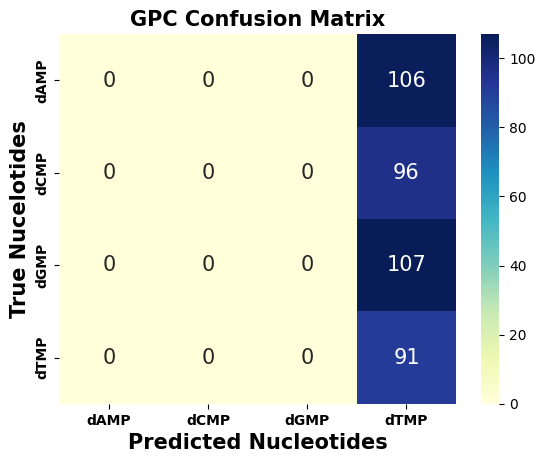

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support
import seaborn as sns
cm = confusion_matrix(y_test, y_pred_gpr)
cm_df = pd.DataFrame(cm,
                     index = ['dAMP','dCMP','dGMP', 'dTMP'],
                     columns = ['dAMP','dCMP','dGMP', 'dTMP'])

sns.heatmap(cm_df, cbar=True,annot=True,cmap="YlGnBu",fmt="d",annot_kws={"size": 15})
plt.ylabel('True Nucelotides', fontsize = 15,weight='bold')
plt.xlabel('Predicted Nucleotides', fontsize = 15,weight='bold')
plt.title('GPC Confusion Matrix', fontsize = 15,weight='bold')
plt.xticks(weight='bold')
plt.yticks(weight='bold')
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_gpr))

              precision    recall  f1-score   support

        dAMP       0.00      0.00      0.00       106
        dCMP       0.00      0.00      0.00        96
        dGMP       0.00      0.00      0.00       107
        dTMP       0.23      1.00      0.37        91

    accuracy                           0.23       400
   macro avg       0.06      0.25      0.09       400
weighted avg       0.05      0.23      0.08       400



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


## **Stochastic Gradient Descent Classifier**

In [ ]:
from sklearn.linear_model import SGDClassifier

sgd = SGDClassifier()

sgd.fit(x_train, y_train)

SGDClassifier()

In [ ]:
y_pred_sgd = sgd.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score

print('Model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, y_pred_sgd)))

Model accuracy score: 0.7850


In [ ]:
print('Training set score: {:.4f}'.format(sgd.score(x_train, y_train)))

print('Test set score: {:.4f}'.format(sgd.score(x_test, y_test)))

Training set score: 0.7913
Test set score: 0.7850


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_sgd))

              precision    recall  f1-score   support

           0       0.76      0.80      0.78       107
           1       0.92      0.82      0.87        99
           2       0.62      0.80      0.70        87
           3       0.89      0.72      0.79       107

    accuracy                           0.79       400
   macro avg       0.80      0.79      0.79       400
weighted avg       0.80      0.79      0.79       400



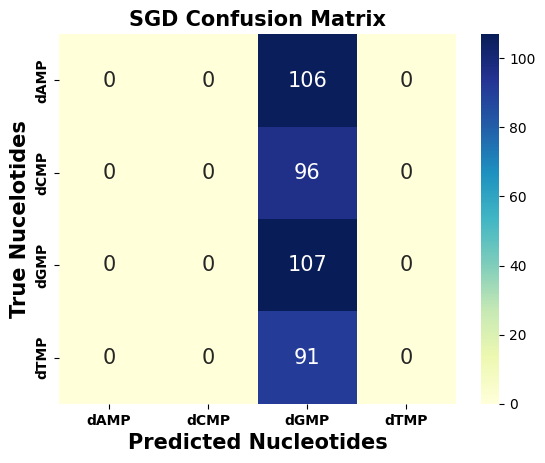

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support
import seaborn as sns
cm = confusion_matrix(y_test, y_pred_sgd)
cm_df = pd.DataFrame(cm,
                     index = ['dAMP','dCMP','dGMP', 'dTMP'],
                     columns = ['dAMP','dCMP','dGMP', 'dTMP'])

sns.heatmap(cm_df, cbar=True,annot=True,cmap="YlGnBu",fmt="d",annot_kws={"size": 15})
plt.ylabel('True Nucelotides', fontsize = 15,weight='bold')
plt.xlabel('Predicted Nucleotides', fontsize = 15,weight='bold')
plt.title('SGD Confusion Matrix', fontsize = 15,weight='bold')
plt.xticks(weight='bold')
plt.yticks(weight='bold')
plt.show()

In [ ]:
sgd.get_params()

{'alpha': 0.0001,
 'average': False,
 'class_weight': None,
 'early_stopping': False,
 'epsilon': 0.1,
 'eta0': 0.0,
 'fit_intercept': True,
 'l1_ratio': 0.15,
 'learning_rate': 'optimal',
 'loss': 'hinge',
 'max_iter': 1000,
 'n_iter_no_change': 5,
 'n_jobs': None,
 'penalty': 'l2',
 'power_t': 0.5,
 'random_state': None,
 'shuffle': True,
 'tol': 0.001,
 'validation_fraction': 0.1,
 'verbose': 0,
 'warm_start': False}